In [1]:
!pip install xgboost shap gradio google-generativeai -q

In [2]:
from google.colab import files
uploaded = files.upload()  # pilih employee_attrition_clean.csv

Saving employee_attrition_clean.csv to employee_attrition_clean.csv


In [3]:
# ngecek data
import pandas as pd

df = pd.read_csv('employee_attrition_clean.csv')
print(df.shape)
df.head()

(1470, 31)


,Age,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EnvironmentSatisfaction,Gender,HourlyRate,...,RelationshipSatisfaction,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager,is_resign
0,41,Travel_Rarely,1102,Sales,1,2,Life Sciences,2,Female,94,...,1,0,8,0,1,6,4,0,5,1
1,49,Travel_Frequently,279,Research & Development,8,1,Life Sciences,3,Male,61,...,4,1,10,3,3,10,7,1,7,0
2,37,Travel_Rarely,1373,Research & Development,2,2,Other,4,Male,92,...,2,0,7,3,3,0,0,0,0,1
3,33,Travel_Frequently,1392,Research & Development,3,4,Life Sciences,4,Female,56,...,3,0,8,3,3,8,7,3,0,0
4,27,Travel_Rarely,591,Research & Development,2,1,Medical,1,Male,40,...,4,1,6,3,3,2,2,2,2,0


In [4]:
# Siapin Fitur
CAT_COLS = ['BusinessTravel', 'Department', 'EducationField', 'Gender',
            'JobRole', 'MaritalStatus', 'OverTime']
NUM_COLS = [c for c in df.columns if c not in CAT_COLS + ['is_resign']]

X = pd.get_dummies(df.drop(columns=['is_resign']), columns=CAT_COLS)
y = df['is_resign']
model_columns = X.columns.tolist()

print(f"{len(NUM_COLS)} fitur numerik, {len(CAT_COLS)} fitur kategorikal -> {X.shape[1]} kolom setelah encoding")

23 fitur numerik, 7 fitur kategorikal -> 51 kolom setelah encoding


In [5]:
# Cambukin Model XGBOOST
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, roc_auc_score, confusion_matrix
import xgboost as xgb

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

scale_pos_weight = (y_train == 0).sum() / (y_train == 1).sum()

model = xgb.XGBClassifier(
    n_estimators=300, max_depth=4, learning_rate=0.05,
    subsample=0.8, colsample_bytree=0.8,
    eval_metric='logloss', scale_pos_weight=scale_pos_weight,
    random_state=42
)
model.fit(X_train, y_train)

pred = model.predict(X_test)
proba = model.predict_proba(X_test)[:, 1]

print(classification_report(y_test, pred, target_names=['Stay', 'Resign']))
print('ROC-AUC:', roc_auc_score(y_test, proba))
print('Confusion matrix:\n', confusion_matrix(y_test, pred))

              precision    recall  f1-score   support

        Stay       0.88      0.93      0.90       247
      Resign       0.47      0.32      0.38        47

    accuracy                           0.83       294
   macro avg       0.67      0.63      0.64       294
weighted avg       0.81      0.83      0.82       294

ROC-AUC: 0.7731070720992332
Confusion matrix:
 [[230  17]
 [ 32  15]]


In [6]:
!pip install seaborn -q

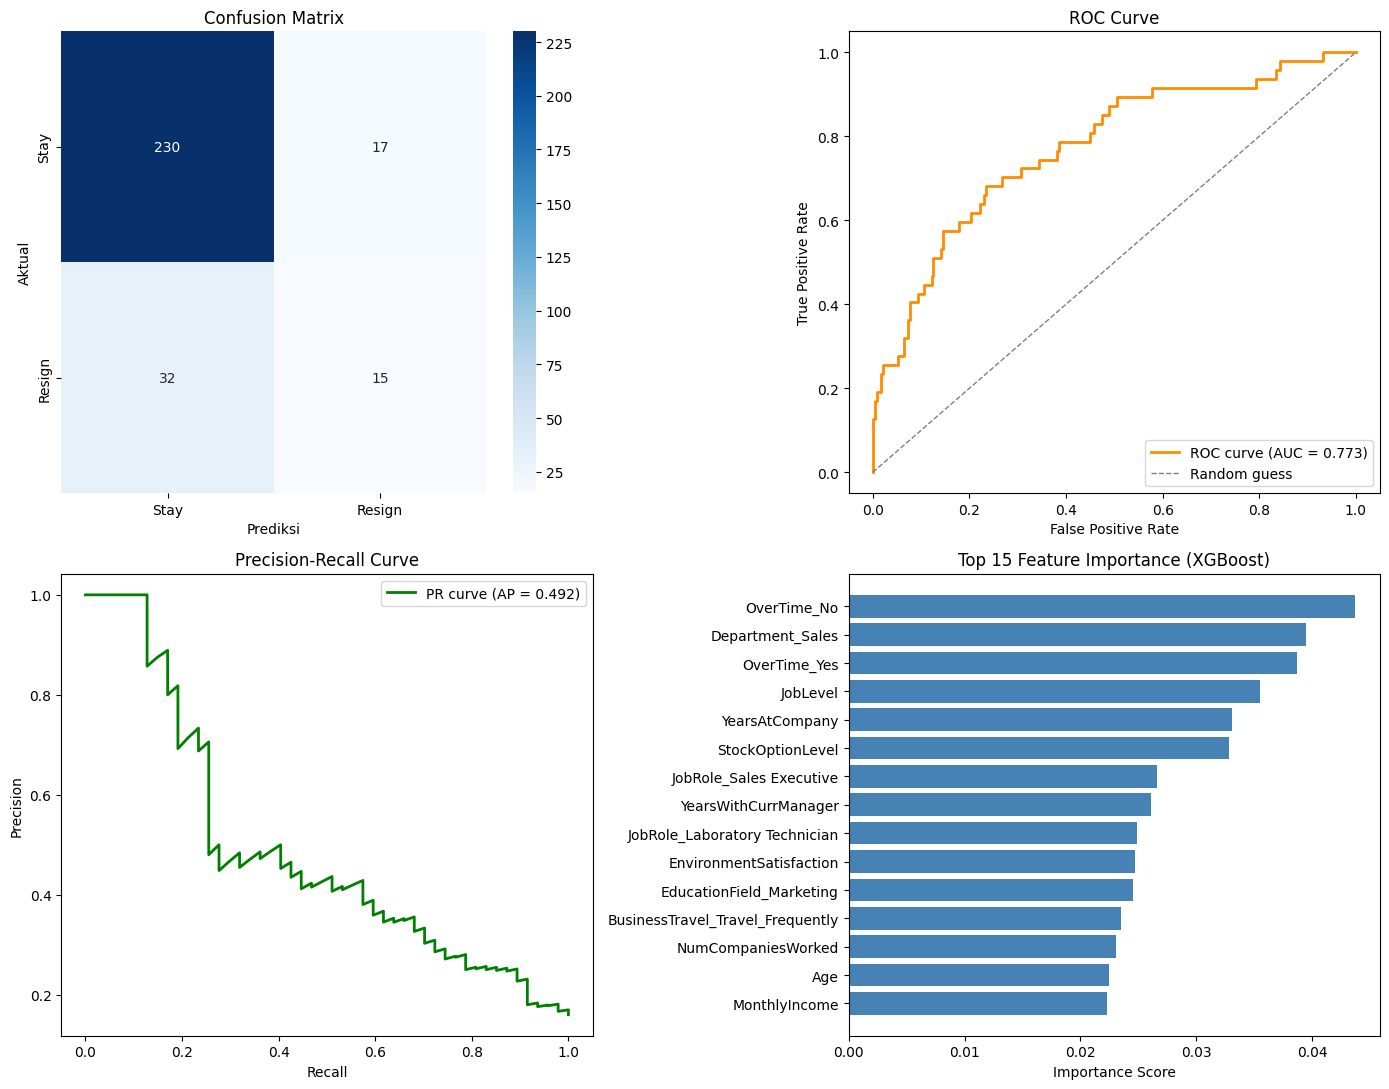

In [7]:
# Graphic Hasil Training
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import (confusion_matrix, roc_curve, auc,
                              precision_recall_curve, average_precision_score)

fig, axes = plt.subplots(2, 2, figsize=(14, 11))

# 1. Confusion Matrix
cm = confusion_matrix(y_test, pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Stay', 'Resign'], yticklabels=['Stay', 'Resign'],
            ax=axes[0, 0])
axes[0, 0].set_title('Confusion Matrix')
axes[0, 0].set_xlabel('Prediksi')
axes[0, 0].set_ylabel('Aktual')

# 2. ROC Curve
fpr, tpr, _ = roc_curve(y_test, proba)
roc_auc = auc(fpr, tpr)
axes[0, 1].plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (AUC = {roc_auc:.3f})')
axes[0, 1].plot([0, 1], [0, 1], color='gray', lw=1, linestyle='--', label='Random guess')
axes[0, 1].set_xlabel('False Positive Rate')
axes[0, 1].set_ylabel('True Positive Rate')
axes[0, 1].set_title('ROC Curve')
axes[0, 1].legend(loc='lower right')

# 3. Precision-Recall Curve
prec, rec, _ = precision_recall_curve(y_test, proba)
ap = average_precision_score(y_test, proba)
axes[1, 0].plot(rec, prec, color='green', lw=2, label=f'PR curve (AP = {ap:.3f})')
axes[1, 0].set_xlabel('Recall')
axes[1, 0].set_ylabel('Precision')
axes[1, 0].set_title('Precision-Recall Curve')
axes[1, 0].legend(loc='upper right')

# 4. Feature Importance (bawaan XGBoost, bukan SHAP)
top_importance = pd.Series(model.feature_importances_, index=X.columns).sort_values(ascending=False).head(15)
axes[1, 1].barh(top_importance.index[::-1], top_importance.values[::-1], color='steelblue')
axes[1, 1].set_title('Top 15 Feature Importance (XGBoost)')
axes[1, 1].set_xlabel('Importance Score')

plt.tight_layout()
plt.savefig('training_evaluation.png', dpi=150, bbox_inches='tight')
plt.show()

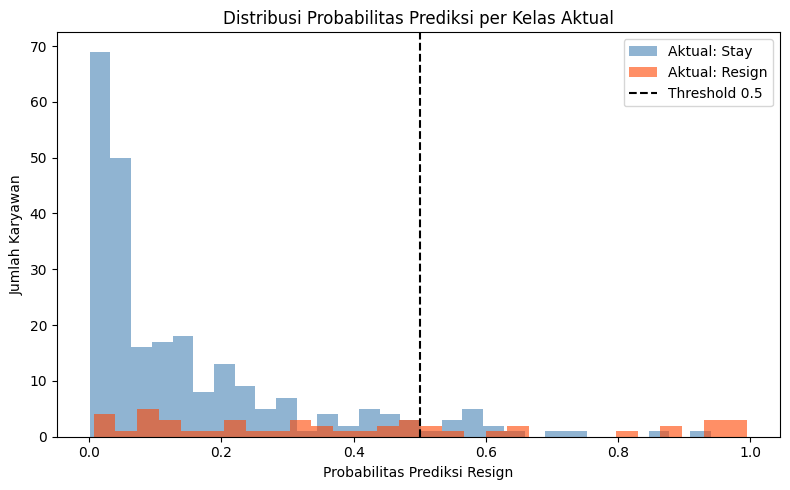

In [8]:
# Bonus: distribusi probabilitas prediksi, dipisah per kelas aktual
plt.figure(figsize=(8, 5))
plt.hist(proba[y_test == 0], bins=30, alpha=0.6, label='Aktual: Stay', color='steelblue')
plt.hist(proba[y_test == 1], bins=30, alpha=0.6, label='Aktual: Resign', color='orangered')
plt.axvline(0.5, color='black', linestyle='--', label='Threshold 0.5')
plt.xlabel('Probabilitas Prediksi Resign')
plt.ylabel('Jumlah Karyawan')
plt.title('Distribusi Probabilitas Prediksi per Kelas Aktual')
plt.legend()
plt.tight_layout()
plt.savefig('probability_distribution.png', dpi=150)
plt.show()

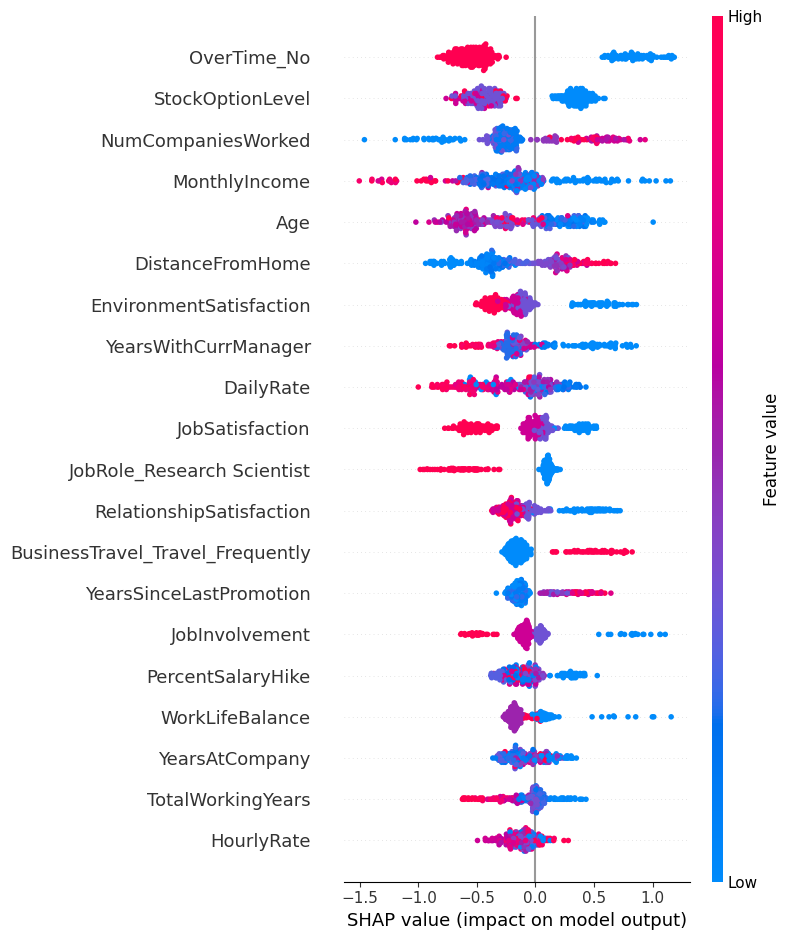

In [9]:
# SHAP global
import shap
import matplotlib.pyplot as plt

explainer = shap.TreeExplainer(model)
shap_values = explainer.shap_values(X_test)

shap.summary_plot(shap_values, X_test, show=False)
plt.tight_layout()
plt.savefig('shap_summary.png', dpi=150)
plt.show()

In [10]:
# Buat Penjelasan per-individu
def explain_employee(idx_in_test, top_n=5):
    row = X_test.iloc[[idx_in_test]]
    proba_resign = model.predict_proba(row)[0][1]

    sv_row = explainer.shap_values(row)[0]
    contrib = pd.Series(sv_row, index=X.columns).sort_values(key=abs, ascending=False)

    top_factors = []
    for feat, val in contrib.head(top_n).items():
        arah = 'meningkatkan risiko resign' if val > 0 else 'menurunkan risiko resign'
        top_factors.append({
            'fitur': feat,
            'nilai_karyawan': row[feat].values[0],
            'kontribusi_shap': round(float(val), 3),
            'arah': arah
        })

    return {'probabilitas_resign': round(float(proba_resign), 3), 'top_factors': top_factors}

hasil = explain_employee(0)
hasil

{'probabilitas_resign': 0.571,
 'top_factors': [{'fitur': 'MonthlyIncome',
   'nilai_karyawan': np.int64(2033),
   'kontribusi_shap': 0.972,
   'arah': 'meningkatkan risiko resign'},
  {'fitur': 'BusinessTravel_Non-Travel',
   'nilai_karyawan': np.True_,
   'kontribusi_shap': -0.893,
   'arah': 'menurunkan risiko resign'},
  {'fitur': 'YearsWithCurrManager',
   'nilai_karyawan': np.int64(0),
   'kontribusi_shap': 0.811,
   'arah': 'meningkatkan risiko resign'},
  {'fitur': 'OverTime_No',
   'nilai_karyawan': np.True_,
   'kontribusi_shap': -0.686,
   'arah': 'menurunkan risiko resign'},
  {'fitur': 'Age',
   'nilai_karyawan': np.int64(24),
   'kontribusi_shap': 0.384,
   'arah': 'meningkatkan risiko resign'}]}

In [11]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler

# Random Forest
rf_model = RandomForestClassifier(
    n_estimators=300, max_depth=8, class_weight='balanced',
    random_state=42, n_jobs=-1
)
rf_model.fit(X_train, y_train)

# Logistic Regression (butuh scaling karena sensitif terhadap skala fitur)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

lr_model = LogisticRegression(max_iter=1000, class_weight='balanced', random_state=42)
lr_model.fit(X_train_scaled, y_train)

print("✅ Random Forest & Logistic Regression selesai dilatih")

✅ Random Forest & Logistic Regression selesai dilatih


In [12]:
# Perbandingan Matrik
from sklearn.metrics import classification_report, roc_auc_score

models_to_compare = {
    'XGBoost': (model, X_test),
    'Random Forest': (rf_model, X_test),
    'Logistic Regression': (lr_model, X_test_scaled),
}

comparison_results = []
for name, (m, xt) in models_to_compare.items():
    pred = m.predict(xt)
    proba = m.predict_proba(xt)[:, 1]
    report = classification_report(y_test, pred, target_names=['Stay', 'Resign'], output_dict=True)
    comparison_results.append({
        'Model': name,
        'ROC-AUC': round(roc_auc_score(y_test, proba), 3),
        'Precision (Resign)': round(report['Resign']['precision'], 3),
        'Recall (Resign)': round(report['Resign']['recall'], 3),
        'F1 (Resign)': round(report['Resign']['f1-score'], 3),
        'Accuracy': round(report['accuracy'], 3),
    })

comparison_df = pd.DataFrame(comparison_results).sort_values('F1 (Resign)', ascending=False)
comparison_df

,Model,ROC-AUC,Precision (Resign),Recall (Resign),F1 (Resign),Accuracy
2,Logistic Regression,0.799,0.333,0.596,0.427,0.745
0,XGBoost,0.773,0.469,0.319,0.380,0.833
1,Random Forest,0.789,0.480,0.255,0.333,0.837


In [13]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import AdaBoostClassifier, GradientBoostingClassifier
from sklearn.svm import SVC
from sklearn.neural_network import MLPClassifier
import lightgbm as lgb

extra_models = {
    'KNN': KNeighborsClassifier(n_neighbors=7, weights='distance'),
    'Decision Tree': DecisionTreeClassifier(max_depth=10, class_weight='balanced', random_state=42),
    'SVM': SVC(C=10, kernel='rbf', gamma='scale', class_weight='balanced', probability=True, random_state=42),
    'AdaBoost': AdaBoostClassifier(n_estimators=100, learning_rate=1.0, random_state=42),
    'Gradient Boosting': GradientBoostingClassifier(n_estimators=100, learning_rate=0.1, max_depth=5, random_state=42),
    'LightGBM': lgb.LGBMClassifier(num_leaves=50, learning_rate=0.1, n_estimators=200, class_weight='balanced', random_state=42, verbosity=-1),
    'MLP': MLPClassifier(hidden_layer_sizes=(100,50), activation='relu', solver='adam', alpha=0.001, max_iter=1000, random_state=42),
}

for name, m in extra_models.items():
    xtr = X_train_scaled if name in ['KNN', 'SVM', 'MLP'] else X_train
    xte = X_test_scaled if name in ['KNN', 'SVM', 'MLP'] else X_test
    m.fit(xtr, y_train)
    pred = m.predict(xte)
    proba = m.predict_proba(xte)[:, 1]
    report = classification_report(y_test, pred, target_names=['Stay', 'Resign'], output_dict=True)
    comparison_results.append({
        'Model': name,
        'ROC-AUC': round(roc_auc_score(y_test, proba), 3),
        'Precision (Resign)': round(report['Resign']['precision'], 3),
        'Recall (Resign)': round(report['Resign']['recall'], 3),
        'F1 (Resign)': round(report['Resign']['f1-score'], 3),
        'Accuracy': round(report['accuracy'], 3),
    })

comparison_df = pd.DataFrame(comparison_results).sort_values('ROC-AUC', ascending=False)
comparison_df

,Model,ROC-AUC,Precision (Resign),Recall (Resign),F1 (Resign),Accuracy
2,Logistic Regression,0.799,0.333,0.596,0.427,0.745
6,AdaBoost,0.798,0.560,0.298,0.389,0.850
7,Gradient Boosting,0.792,0.562,0.191,0.286,0.847
1,Random Forest,0.789,0.480,0.255,0.333,0.837
8,LightGBM,0.788,0.519,0.298,0.378,0.844
0,XGBoost,0.773,0.469,0.319,0.380,0.833
5,SVM,0.714,0.406,0.277,0.329,0.820
9,MLP,0.695,0.529,0.383,0.444,0.847
3,KNN,0.689,0.600,0.128,0.211,0.847
4,Decision Tree,0.531,0.222,0.213,0.217,0.755


In [14]:
!pip install groq -q
from groq import Groq
GROQ_API_KEY = "GROQ_API_KEY_ANDA"
groq_client = Groq(api_key=GROQ_API_KEY)

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 143.8/143.8 kB 3.6 MB/s eta 0:00:00


In [15]:
# Buat Nasari dari si AI
def generate_hr_narrative(employee_info, shap_result):
    proba = shap_result['probabilitas_resign']
    if proba < 0.30:
        risk_tier = "RENDAH"
        instruksi_ringkasan = (
            "Karena risiko RENDAH (kepuasan tinggi), jelaskan: (a) mengapa nilai resign ini bisa rendah "
            "berdasarkan data yang ada, dan (b) hal-hal apa yang harus DIPERTAHANKAN agar kondisi ini tetap terjaga."
        )
    elif proba < 0.60:
        risk_tier = "SEDANG"
        instruksi_ringkasan = (
            "Karena risiko SEDANG, jelaskan faktor yang mulai menunjukkan tanda ketidakpuasan dan "
            "langkah pencegahan dini yang bisa diambil sebelum risiko meningkat."
        )
    else:
        risk_tier = "TINGGI"
        instruksi_ringkasan = (
            "Karena risiko TINGGI (kepuasan rendah), jelaskan: (a) mengapa nilai resign ini bisa tinggi "
            "berdasarkan data, dan (b) faktor apa yang paling mempengaruhi serta rekomendasi improvisasi konkret."
        )

    prompt = f"""
Kamu adalah HR Business Partner yang berpengalaman menganalisis risiko attrition karyawan.
Klasifikasi risiko ini mengikuti kerangka risk-tiering dari Pavithran & Vadivel (2026, Frontiers in Big Data):
Rendah (<30%), Sedang (30-60%), Tinggi (>60%).

Data karyawan:
{employee_info}

Probabilitas resign: {proba*100:.1f}% -> Kategori risiko: {risk_tier}

Faktor-faktor pendorong utama (dari analisis SHAP):
{shap_result['top_factors']}

Tugas kamu untuk bagian "Ringkasan":
{instruksi_ringkasan}

Untuk bagian "Faktor Utama": sebutkan 2-3 faktor paling dominan dan jelaskan maknanya secara bisnis.

Untuk bagian "Rekomendasi": berikan 2-3 rekomendasi tindakan konkret sesuai kategori risiko
(pertahankan untuk Rendah, pantau untuk Sedang, intervensi aktif untuk Tinggi).

Format jawaban dengan heading: Ringkasan, Faktor Utama, Rekomendasi.
"""
    response = groq_client.chat.completions.create(
        model="openai/gpt-oss-120b",
        messages=[
            {"role": "system", "content": "Kamu adalah HR Business Partner berpengalaman yang menjawab dalam Bahasa Indonesia."},
            {"role": "user", "content": prompt}
        ],
        temperature=0.4,
    )
    return response.choices[0].message.content

In [16]:
import gradio as gr
import matplotlib.pyplot as plt

cat_options = {c: sorted(df[c].unique().tolist()) for c in CAT_COLS}

FIELDS = [
    'Age', 'DistanceFromHome', 'Education', 'JobLevel', 'TotalWorkingYears',
    'YearsAtCompany', 'YearsInCurrentRole', 'YearsSinceLastPromotion', 'YearsWithCurrManager',
    'NumCompaniesWorked', 'MonthlyIncome', 'PercentSalaryHike', 'StockOptionLevel',
    'PerformanceRating', 'TrainingTimesLastYear', 'EnvironmentSatisfaction', 'JobSatisfaction',
    'JobInvolvement', 'RelationshipSatisfaction', 'WorkLifeBalance',
    'BusinessTravel', 'Department', 'EducationField', 'Gender', 'JobRole', 'MaritalStatus', 'OverTime',
]

# ============================================================
# MODEL AKTIF: Logistic Regression (ROC-AUC & Recall terbaik dari perbandingan)
# ============================================================
active_model = lr_model
active_explainer = shap.LinearExplainer(active_model, X_train_scaled)

# ============================================================
# FUNGSI INTI (dipakai bareng oleh semua tab)
# ============================================================
def run_prediction(raw_row: dict, employee_label_info: dict):
    try:
        row = {c: 0 for c in model_columns}
        for col in NUM_COLS:
            row[col] = raw_row[col]
        for col in CAT_COLS:
            key = f"{col}_{raw_row[col]}"
            if key in row:
                row[key] = 1

        row_df = pd.DataFrame([row])[model_columns]
        row_scaled = scaler.transform(row_df)

        proba = active_model.predict_proba(row_scaled)[0][1]

        exp = active_explainer(row_scaled)
        exp_single = exp[0]
        exp_single.data = row_df.iloc[0].values
        exp_single.feature_names = model_columns

        sv = pd.Series(exp.values[0], index=model_columns).sort_values(key=abs, ascending=False)
        top_factors = [{'fitur': f, 'kontribusi_shap': round(float(v), 3),
                         'arah': 'meningkatkan risiko resign' if v > 0 else 'menurunkan risiko resign'}
                        for f, v in sv.head(5).items()]

        fig, ax = plt.subplots(figsize=(8, 5))
        shap.plots.waterfall(exp_single, show=False)
        plt.tight_layout()
        plot_path = 'waterfall_temp.png'
        plt.savefig(plot_path, dpi=150)
        plt.close()

        shap_result = {'probabilitas_resign': proba, 'top_factors': top_factors}

        try:
            narasi = generate_hr_narrative(employee_label_info, shap_result)
        except Exception as e:
            narasi = f"⚠️ Prediksi & SHAP berhasil, tapi narasi LLM gagal: `{type(e).__name__}: {e}`"

        label = f"{proba*100:.1f}% kemungkinan resign"
        return label, plot_path, narasi

    except Exception as e:
        import traceback
        error_detail = traceback.format_exc()
        print(error_detail)  # tetap tercetak di log Colab untuk debug lengkap
        return f"❌ Error: {type(e).__name__}: {e}", None, "Lihat log Colab untuk detail lengkap."


def build_raw_row(values: dict, hidden_rates: dict = None):
    raw_row = dict(values)
    hidden_rates = hidden_rates or {}
    raw_row['DailyRate'] = hidden_rates.get('DailyRate', int(df['DailyRate'].median()))
    raw_row['HourlyRate'] = hidden_rates.get('HourlyRate', int(df['HourlyRate'].median()))
    raw_row['MonthlyRate'] = hidden_rates.get('MonthlyRate', int(df['MonthlyRate'].median()))
    return raw_row


def pick_info(values: dict):
    keys = [k for k in ['JobRole', 'Department', 'Age', 'YearsAtCompany', 'OverTime'] if k in values]
    return {k: values[k] for k in keys}


# ============================================================
# FACTORY: bikin form input karyawan (dipakai di Tab Manual & Tab Eksperimen CSV)
# ============================================================
def create_employee_inputs(defaults=None):
    """Membuat sekumpulan slider & dropdown. Kembalikan dict {field_name: component}."""
    d = defaults or {}
    comps = {}

    with gr.Row():
        with gr.Column():
            gr.Markdown("**Data Demografi & Pekerjaan**")
            comps['Age'] = gr.Slider(18, 60, value=d.get('Age', 35), step=1, label="Umur")
            comps['DistanceFromHome'] = gr.Slider(1, 30, value=d.get('DistanceFromHome', 5), step=1, label="Jarak dari Rumah (km)")
            comps['Education'] = gr.Slider(1, 5, value=d.get('Education', 3), step=1, label="Level Pendidikan (1=SMA...5=S3)")
            comps['JobLevel'] = gr.Slider(1, 5, value=d.get('JobLevel', 2), step=1, label="Job Level")
            comps['TotalWorkingYears'] = gr.Slider(0, 40, value=d.get('TotalWorkingYears', 8), step=1, label="Total Tahun Bekerja")
            comps['YearsAtCompany'] = gr.Slider(0, 40, value=d.get('YearsAtCompany', 5), step=1, label="Tahun di Perusahaan Ini")
            comps['YearsInCurrentRole'] = gr.Slider(0, 20, value=d.get('YearsInCurrentRole', 3), step=1, label="Tahun di Posisi Sekarang")
            comps['YearsSinceLastPromotion'] = gr.Slider(0, 15, value=d.get('YearsSinceLastPromotion', 1), step=1, label="Tahun Sejak Promosi Terakhir")
            comps['YearsWithCurrManager'] = gr.Slider(0, 20, value=d.get('YearsWithCurrManager', 3), step=1, label="Tahun dengan Manager Sekarang")
            comps['NumCompaniesWorked'] = gr.Slider(0, 10, value=d.get('NumCompaniesWorked', 2), step=1, label="Jumlah Perusahaan Sebelumnya")

            gr.Markdown("**Kompensasi & Karir**")
            comps['MonthlyIncome'] = gr.Slider(1000, 20000, value=d.get('MonthlyIncome', 5000), step=1, label="Gaji Bulanan")
            comps['PercentSalaryHike'] = gr.Slider(10, 25, value=d.get('PercentSalaryHike', 13), step=1, label="Persen Kenaikan Gaji Terakhir")
            comps['StockOptionLevel'] = gr.Slider(0, 3, value=d.get('StockOptionLevel', 1), step=1, label="Stock Option Level")
            comps['PerformanceRating'] = gr.Slider(1, 4, value=d.get('PerformanceRating', 3), step=1, label="Performance Rating")
            comps['TrainingTimesLastYear'] = gr.Slider(0, 6, value=d.get('TrainingTimesLastYear', 2), step=1, label="Frekuensi Training/Tahun")

        with gr.Column():
            gr.Markdown("**Kepuasan Kerja**")
            comps['EnvironmentSatisfaction'] = gr.Slider(1, 4, value=d.get('EnvironmentSatisfaction', 3), step=1, label="Kepuasan Lingkungan Kerja")
            comps['JobSatisfaction'] = gr.Slider(1, 4, value=d.get('JobSatisfaction', 3), step=1, label="Kepuasan Kerja")
            comps['JobInvolvement'] = gr.Slider(1, 4, value=d.get('JobInvolvement', 3), step=1, label="Keterlibatan Kerja")
            comps['RelationshipSatisfaction'] = gr.Slider(1, 4, value=d.get('RelationshipSatisfaction', 3), step=1, label="Kepuasan Relasi Kerja")
            comps['WorkLifeBalance'] = gr.Slider(1, 4, value=d.get('WorkLifeBalance', 3), step=1, label="Work-Life Balance")

            gr.Markdown("**Kategori**")
            comps['BusinessTravel'] = gr.Dropdown(cat_options['BusinessTravel'], value=d.get('BusinessTravel', cat_options['BusinessTravel'][0]), label="Frekuensi Perjalanan Dinas")
            comps['Department'] = gr.Dropdown(cat_options['Department'], value=d.get('Department', cat_options['Department'][0]), label="Departemen")
            comps['EducationField'] = gr.Dropdown(cat_options['EducationField'], value=d.get('EducationField', cat_options['EducationField'][0]), label="Bidang Pendidikan")
            comps['Gender'] = gr.Dropdown(cat_options['Gender'], value=d.get('Gender', cat_options['Gender'][0]), label="Gender")
            comps['JobRole'] = gr.Dropdown(cat_options['JobRole'], value=d.get('JobRole', cat_options['JobRole'][0]), label="Job Role")
            comps['MaritalStatus'] = gr.Dropdown(cat_options['MaritalStatus'], value=d.get('MaritalStatus', cat_options['MaritalStatus'][0]), label="Status Pernikahan")
            comps['OverTime'] = gr.Dropdown(cat_options['OverTime'], value=d.get('OverTime', cat_options['OverTime'][0]), label="Sering Lembur?")

    return comps


# ============================================================
# UI
# ============================================================
with gr.Blocks(title="AI Employee Attrition Detector") as demo:
    gr.Markdown("# 🔍 AI Employee Attrition Detector\nPrediksi risiko resign + penjelasan XAI + rekomendasi HR. *(Model: Logistic Regression — ROC-AUC & Recall terbaik)*")

    with gr.Tabs():
        # ---------------- TAB 1: INPUT MANUAL ----------------
        with gr.Tab("📝 Input Manual"):
            manual_inputs = create_employee_inputs()

            btn_manual = gr.Button("🔮 Prediksi & Jelaskan", variant="primary")
            out_label_manual = gr.Textbox(label="Hasil Prediksi")
            out_plot_manual = gr.Image(label="SHAP Waterfall (faktor pendorong)")
            out_narasi_manual = gr.Markdown(label="Narasi HR (dari LLM)")

            def predict_manual(*values):
                raw_row = build_raw_row(dict(zip(FIELDS, values)))
                info = pick_info(dict(zip(FIELDS, values)))
                return run_prediction(raw_row, info)

            btn_manual.click(
                predict_manual,
                inputs=[manual_inputs[f] for f in FIELDS],
                outputs=[out_label_manual, out_plot_manual, out_narasi_manual]
            )

        # ---------------- TAB 2: UPLOAD CSV ----------------
        with gr.Tab("📁 Upload CSV"):
            gr.Markdown("Upload CSV hasil cleaning dari Notebook A (kolom harus sama seperti data training).")
            csv_state = gr.State(None)

            file_upload = gr.File(label="Drag & drop CSV karyawan di sini", file_types=[".csv"])
            upload_status = gr.Markdown("")
            row_dropdown = gr.Dropdown(choices=[], label="Pilih Karyawan (baris di CSV)")

            def load_csv(file):
                if file is None:
                    return gr.update(choices=[], value=None), None, "Belum ada file diupload."
                csv_df = pd.read_csv(file.name)
                required = NUM_COLS + CAT_COLS
                missing = [c for c in required if c not in csv_df.columns]
                if missing:
                    return gr.update(choices=[], value=None), None, f"⚠️ Kolom hilang di CSV: {missing}"
                choices = [f"Baris {i+1} - {row['JobRole']} - {row['Department']} - Umur {row['Age']}"
                           for i, row in csv_df.iterrows()]
                status = f"✅ {len(csv_df)} baris berhasil dimuat."
                return gr.update(choices=choices, value=choices[0] if choices else None), csv_df, status

            file_upload.upload(load_csv, inputs=[file_upload], outputs=[row_dropdown, csv_state, upload_status])

            gr.Markdown("### Prediksi Data Asli")
            btn_csv = gr.Button("🔮 Prediksi Karyawan Ini (Data Asli)", variant="primary")
            out_label_csv = gr.Textbox(label="Hasil Prediksi")
            out_plot_csv = gr.Image(label="SHAP Waterfall (faktor pendorong)")
            out_narasi_csv = gr.Markdown(label="Narasi HR (dari LLM)")

            def predict_from_csv(selected_label, csv_df):
                if csv_df is None or selected_label is None:
                    return "Upload CSV dan pilih baris terlebih dahulu.", None, ""
                row_idx = int(selected_label.split(" ")[1]) - 1
                raw_row = csv_df.iloc[row_idx].to_dict()
                info = pick_info(raw_row)
                label, plot_path, narasi = run_prediction(raw_row, info)
                if 'is_resign' in raw_row:
                    aktual = "Resign" if raw_row['is_resign'] == 1 else "Stay"
                    label += f"  |  Data aktual: **{aktual}**"
                return label, plot_path, narasi

            btn_csv.click(predict_from_csv, inputs=[row_dropdown, csv_state], outputs=[out_label_csv, out_plot_csv, out_narasi_csv])

            gr.Markdown("---")
            gr.Markdown(
                "### 🧪 Eksperimen: Ubah Data Karyawan Ini (Sementara)\n"
                "Form di bawah otomatis terisi data karyawan yang kamu pilih di atas. "
                "Ubah nilainya untuk melihat simulasi 'bagaimana jika' — **perubahan ini tidak mengubah file CSV asli**, "
                "hanya dipakai untuk prediksi sekali ini."
            )
            experiment_inputs = create_employee_inputs()
            hidden_rates_state = gr.State({})

            def populate_experiment_form(selected_label, csv_df):
                if csv_df is None or selected_label is None:
                    return [gr.update() for _ in FIELDS] + [{}]
                row_idx = int(selected_label.split(" ")[1]) - 1
                raw_row = csv_df.iloc[row_idx].to_dict()
                hidden_rates = {
                    'DailyRate': raw_row.get('DailyRate', int(df['DailyRate'].median())),
                    'HourlyRate': raw_row.get('HourlyRate', int(df['HourlyRate'].median())),
                    'MonthlyRate': raw_row.get('MonthlyRate', int(df['MonthlyRate'].median())),
                }
                return [raw_row.get(f) for f in FIELDS] + [hidden_rates]

            row_dropdown.change(
                populate_experiment_form,
                inputs=[row_dropdown, csv_state],
                outputs=[experiment_inputs[f] for f in FIELDS] + [hidden_rates_state]
            )

            btn_experiment = gr.Button("🔮 Prediksi dengan Data yang Diubah (Eksperimen)", variant="secondary")
            out_label_exp = gr.Textbox(label="Hasil Prediksi (Eksperimen)")
            out_plot_exp = gr.Image(label="SHAP Waterfall (Eksperimen)")
            out_narasi_exp = gr.Markdown(label="Narasi HR - Eksperimen (dari LLM)")

            def predict_experiment(*args):
                *values, hidden_rates = args
                raw_row = build_raw_row(dict(zip(FIELDS, values)), hidden_rates)
                info = pick_info(dict(zip(FIELDS, values)))
                return run_prediction(raw_row, info)

            btn_experiment.click(
                predict_experiment,
                inputs=[experiment_inputs[f] for f in FIELDS] + [hidden_rates_state],
                outputs=[out_label_exp, out_plot_exp, out_narasi_exp]
            )

In [ ]:
demo.launch(share=True, debug=True)

Colab notebook detected. This cell will run indefinitely so that you can see errors and logs. To turn off, set debug=False in launch().
* Running on public URL: https://c04ac8a20f00004adb.gradio.live

This share link is temporary and will last for up to 1 week (best effort). For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)
